# Module 3 — Clustering


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings('ignore')
SEED = 42
print('Imports OK')

Imports OK


## 1. Chargement et préparation des données


In [2]:
df = pd.read_csv('outputs/full_cleaned.csv')

FEATURES = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite']
feat_clust = [c for c in FEATURES if c in df.columns]

X_raw  = df[feat_clust].copy()
y_true = df['Categorie'].values if 'Categorie' in df.columns else None

# Standardisation
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f'Shape : {X.shape}')
print(f'Features : {feat_clust}')

Shape : (9986, 5)
Features : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite']


## 2. Choix du nombre de clusters (Elbow + Silhouette)


Elbow=2 | Silhouette=5 | DB=4 | CH=4
=> k optimal retenu : 4


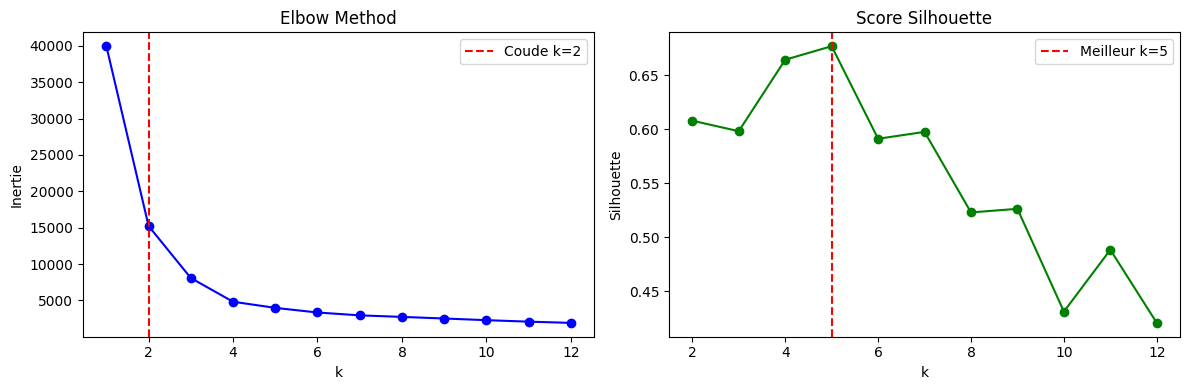

In [3]:
K_MAX = 12
inertia, sil_scores, db_scores, ch_scores = [], [], [], []

for k in range(1, K_MAX + 1):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEED)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    if k >= 2:
        sil_scores.append(silhouette_score(X, labels))
        db_scores.append(davies_bouldin_score(X, labels))
        ch_scores.append(calinski_harabasz_score(X, labels))

# Coude automatique
elbow_idx = np.argmax(np.diff(np.diff(inertia))) + 2
best_k_sil = np.argmax(sil_scores) + 2
best_k_db  = np.argmin(db_scores) + 2
best_k_ch  = np.argmax(ch_scores) + 2

# Vote
K_OPTIMAL = Counter([elbow_idx, best_k_sil, best_k_db, best_k_ch]).most_common(1)[0][0]
print(f'Elbow={elbow_idx} | Silhouette={best_k_sil} | DB={best_k_db} | CH={best_k_ch}')
print(f'=> k optimal retenu : {K_OPTIMAL}')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, K_MAX+1), inertia, 'bo-')
axes[0].axvline(x=elbow_idx, color='red', linestyle='--', label=f'Coude k={elbow_idx}')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertie')
axes[0].legend()

axes[1].plot(range(2, K_MAX+1), sil_scores, 'go-')
axes[1].axvline(x=best_k_sil, color='red', linestyle='--', label=f'Meilleur k={best_k_sil}')
axes[1].set_title('Score Silhouette')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. KMeans — Clustering final


In [4]:
km = KMeans(n_clusters=K_OPTIMAL, init='k-means++', n_init=20, random_state=SEED)
km_labels = km.fit_predict(X)

print(f'Silhouette     : {silhouette_score(X, km_labels):.4f}')
print(f'Davies-Bouldin : {davies_bouldin_score(X, km_labels):.4f}')
print(f'Calinski-Harab.: {calinski_harabasz_score(X, km_labels):.2f}')
print()
counts = pd.Series(km_labels).value_counts().sort_index()
for c, n in counts.items():
    print(f'  Cluster {c} : {n} points ({n/len(km_labels)*100:.1f}%)')

Silhouette     : 0.6644
Davies-Bouldin : 0.4757
Calinski-Harab.: 24285.60

  Cluster 0 : 2775 points (27.8%)
  Cluster 1 : 2529 points (25.3%)
  Cluster 2 : 2336 points (23.4%)
  Cluster 3 : 2346 points (23.5%)


## 4. DBSCAN — Clustering par densité


In [5]:
from sklearn.neighbors import NearestNeighbors

# Chercher le meilleur eps
best_eps, best_sil_db = 0.5, -1
for eps in np.arange(0.3, 2.5, 0.1):
    db = DBSCAN(eps=round(eps, 2), min_samples=5)
    labels = db.fit_predict(X)
    n_clus = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clus >= 2:
        mask = labels != -1
        sil = silhouette_score(X[mask], labels[mask]) if mask.sum() > 1 else -1
        if sil > best_sil_db:
            best_sil_db, best_eps = sil, round(eps, 2)

dbscan    = DBSCAN(eps=best_eps, min_samples=5)
db_labels = dbscan.fit_predict(X)
n_clus    = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise   = (db_labels == -1).sum()

print(f'eps={best_eps} | Clusters={n_clus} | Outliers={n_noise} ({n_noise/len(db_labels)*100:.1f}%)')
if n_clus >= 2:
    mask = db_labels != -1
    db_sil = silhouette_score(X[mask], db_labels[mask])
    print(f'Silhouette : {db_sil:.4f}')
else:
    db_sil = -1
    print('Moins de 2 clusters — ajuster eps')

eps=0.8 | Clusters=13 | Outliers=5 (0.1%)
Silhouette : 0.6834


## 5. Clustering Agglomératif + Dendrogramme


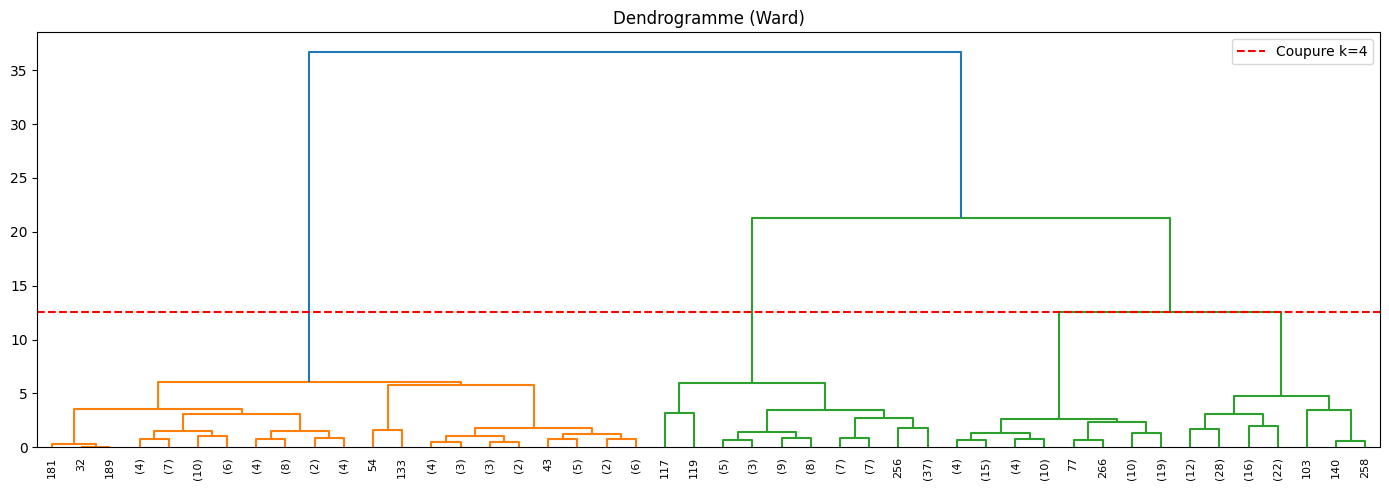

Silhouette     : 0.6565
Davies-Bouldin : 0.4901


In [6]:
# Dendrogramme (sur échantillon)
idx = np.random.choice(len(X), min(300, len(X)), replace=False)
Z   = linkage(X[idx], method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='level', p=5, leaf_rotation=90)
plt.axhline(y=Z[-K_OPTIMAL+1, 2], color='red', linestyle='--', label=f'Coupure k={K_OPTIMAL}')
plt.title('Dendrogramme (Ward)')
plt.legend()
plt.tight_layout()
plt.show()

# Clustering complet
agg = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
agg_labels = agg.fit_predict(X)

print(f'Silhouette     : {silhouette_score(X, agg_labels):.4f}')
print(f'Davies-Bouldin : {davies_bouldin_score(X, agg_labels):.4f}')

## 6. Visualisation PCA 2D


Variance expliquée : PC1=73.5%  PC2=17.7%  Total=91.2%


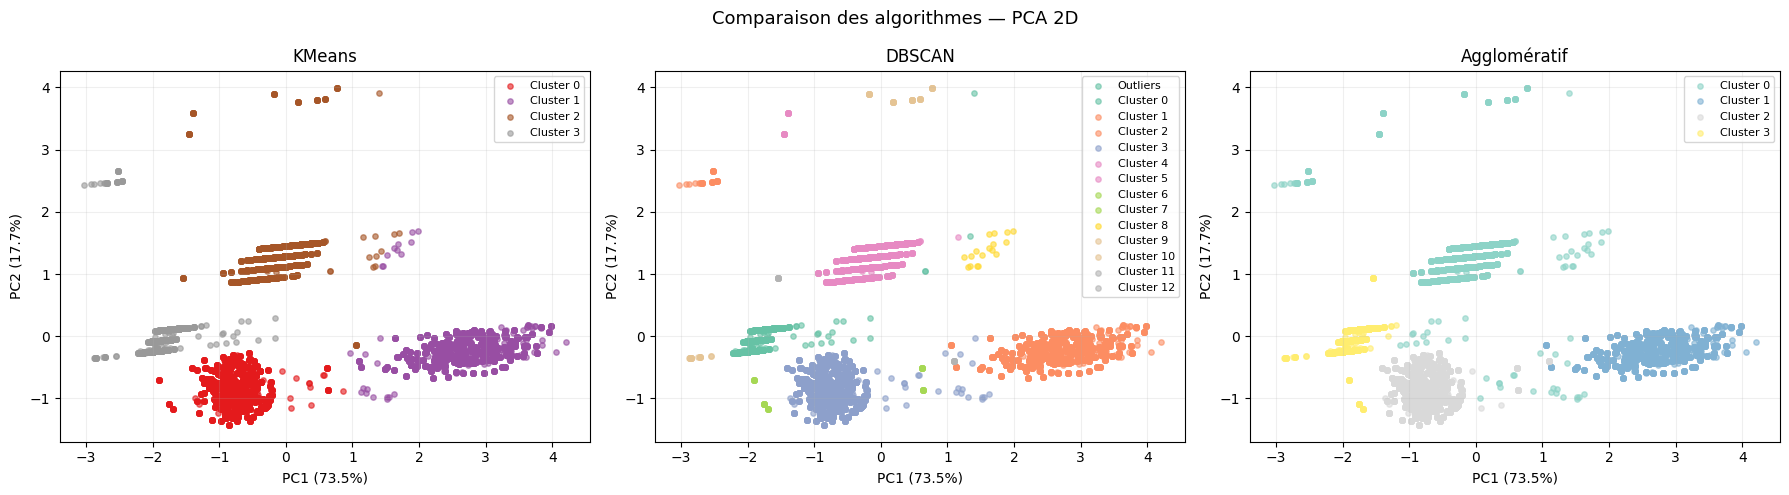

In [7]:
pca   = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X)
v1, v2 = pca.explained_variance_ratio_ * 100
print(f'Variance expliquée : PC1={v1:.1f}%  PC2={v2:.1f}%  Total={v1+v2:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
configs = [
    (km_labels,  'KMeans',        'Set1'),
    (db_labels,  'DBSCAN',        'Set2'),
    (agg_labels, 'Agglomératif',  'Set3'),
]

for ax, (labels, title, cmap) in zip(axes, configs):
    unique = sorted(set(labels))
    colors = plt.cm.get_cmap(cmap)(np.linspace(0, 1, len(unique)))
    for lbl, color in zip(unique, colors):
        mask = labels == lbl
        name = f'Cluster {lbl}' if lbl != -1 else 'Outliers'
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], s=15, alpha=0.6, label=name)
    ax.set_title(title)
    ax.set_xlabel(f'PC1 ({v1:.1f}%)')
    ax.set_ylabel(f'PC2 ({v2:.1f}%)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle('Comparaison des algorithmes — PCA 2D', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Profil des clusters (KMeans)


Moyennes par cluster :


,Poids,Volume,Conductivite,Opacite,Rigidite
Cluster,,,,,
0,27.596,60.896,0.0,0.398,4.024
1,184.308,357.660,0.0,0.107,9.074
2,62.281,124.750,0.0,1.034,8.573
3,14.933,33.461,0.0,1.022,2.023


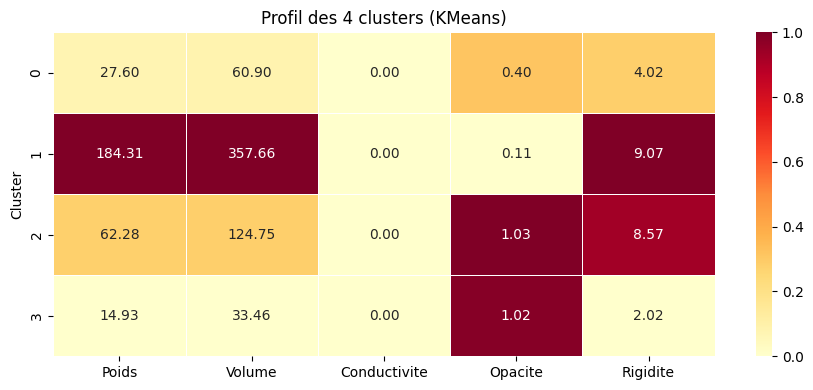

In [8]:
df_res = X_raw.copy()
df_res['Cluster'] = km_labels

profiles = df_res.groupby('Cluster')[feat_clust].mean().round(3)
print('Moyennes par cluster :')
display(profiles)

# Heatmap
norm = (profiles - profiles.min()) / (profiles.max() - profiles.min() + 1e-9)
plt.figure(figsize=(9, 4))
sns.heatmap(norm, annot=profiles.round(2), fmt='.2f',
            cmap='YlOrRd', linewidths=0.5)
plt.title(f'Profil des {K_OPTIMAL} clusters (KMeans)')
plt.tight_layout()
plt.show()

## 8. Résumé comparatif


In [9]:
km_sil  = silhouette_score(X, km_labels)
km_db   = davies_bouldin_score(X, km_labels)
agg_sil = silhouette_score(X, agg_labels)
agg_db  = davies_bouldin_score(X, agg_labels)

rows = [
    {'Algorithme': 'KMeans',       'Silhouette': km_sil,  'Davies-Bouldin': km_db},
    {'Algorithme': 'Agglomératif', 'Silhouette': agg_sil, 'Davies-Bouldin': agg_db},
]
if db_sil != -1:
    rows.append({'Algorithme': f'DBSCAN (eps={best_eps})', 'Silhouette': db_sil, 'Davies-Bouldin': None})

summary = pd.DataFrame(rows).set_index('Algorithme').round(4)
display(summary)

best = 'KMeans' if km_sil >= agg_sil else 'Agglomératif'
print(f'\nMeilleur algorithme : {best}  |  k = {K_OPTIMAL}')

,Silhouette,Davies-Bouldin
Algorithme,,
KMeans,0.6644,0.4757
Agglomératif,0.6565,0.4901
DBSCAN (eps=0.8),0.6834,NaN



Meilleur algorithme : KMeans  |  k = 4


## 9. Sauvegarde


In [10]:
import os
os.makedirs('outputs', exist_ok=True)

df_out = df.copy()
df_out['Cluster_KMeans']  = km_labels
df_out['Cluster_Agg']     = agg_labels
df_out['Cluster_DBSCAN']  = db_labels
df_out['PCA_1'] = X_pca[:, 0]
df_out['PCA_2'] = X_pca[:, 1]

df_out.to_csv('outputs/clustering_results.csv', index=False)
print(f'Sauvegardé : outputs/clustering_results.csv  ({df_out.shape})')

Sauvegardé : outputs/clustering_results.csv  ((9986, 13))
